<a href="https://colab.research.google.com/github/kk5190/ai-powered-tourism-analytics/blob/main/Krishna_Preserving_Heritage_Enhancing_Tourism_with_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Powered Heritage Structure Classification & Tourism Recommendation System

This project combines deep learning and recommendation systems to enhance the tourism domain.
It classifies historical architecture images and recommends tourist places based on user preferences.

## 1. Importing Libraries
We import all essential libraries for image handling, deep learning, and recommendation system development.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from PIL import Image, ImageFile
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics.pairwise import cosine_similarity
from scipy import sparse

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True


## 2. Defining Dataset Paths
Paths to training, testing, and output directories.


In [ ]:
asets_path = "/content/drive/MyDrive/CapstoneProjectAssets/Capstone2"
train_images_path = os.path.join(asets_path, 'Part1/dataset_hist_structures/Stuctures_Dataset')
test_images_path = os.path.join(asets_path, 'Part1/dataset_hist_structures/Dataset_test/Dataset_test_original_1478')
output_images_path = os.path.join(asets_path, 'output')


## 3. Helper Functions
Reusable functions for exploring data, visualizing images, and building models.


In [ ]:
def list_image_stats(rootdir):
    total_images, class_counts = 0, {}
    for cls in os.listdir(rootdir):
        cls_path = os.path.join(rootdir, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('jpg', 'jpeg', 'png', 'gif'))]
        class_counts[cls] = len(images)
        total_images += len(images)
    print(f"Total Images: {total_images}")
    for cls, count in class_counts.items():
        print(f"{cls}: {count} ({(count/total_images)*100:.2f}%)")

def plot_sample_images(rootdir, samples_per_class=8):
    images, labels = [], []
    for cls in os.listdir(rootdir):
        cls_path = os.path.join(rootdir, cls)
        imgs = [os.path.join(cls_path, f) for f in os.listdir(cls_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))]
        selected_imgs = random.sample(imgs, min(len(imgs), samples_per_class))
        for img_path in selected_imgs:
            img = Image.open(img_path).resize((128,128))
            images.append(img)
            labels.append(cls)
    cols = samples_per_class
    rows = len(set(labels))
    fig, axs = plt.subplots(rows, cols, figsize=(15, 2.5 * rows))
    for idx, (img, lbl) in enumerate(zip(images, labels)):
        r, c = divmod(idx, cols)
        axs[r, c].imshow(img)
        axs[r, c].axis('off')
        if c == 0:
            axs[r, c].set_title(lbl)
    plt.tight_layout()
    plt.show()

def create_model(num_classes):
    """Build and compile CNN using transfer learning."""
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(1024, activation='relu')(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(base_model.input, output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy', Precision(), Recall()])
    return model

def plot_training(history):
    """Visualize training and validation performance."""
    pd.DataFrame(history.history)[['accuracy','val_accuracy','loss','val_loss']].plot(figsize=(10,6), grid=True)
    plt.title("Training & Validation Performance")
    plt.show()

## 4. Data Exploration
View dataset structure and sample images from each class.


Total Images: 10336
bell_tower: 1059 (10.25%)
dome(inner): 616 (5.96%)
flying_buttress: 407 (3.94%)
column: 1929 (18.66%)
stained_glass: 1033 (9.99%)
dome(outer): 1177 (11.39%)
gargoyle: 1591 (15.39%)
vault: 1110 (10.74%)
apse: 553 (5.35%)
altar: 861 (8.33%)


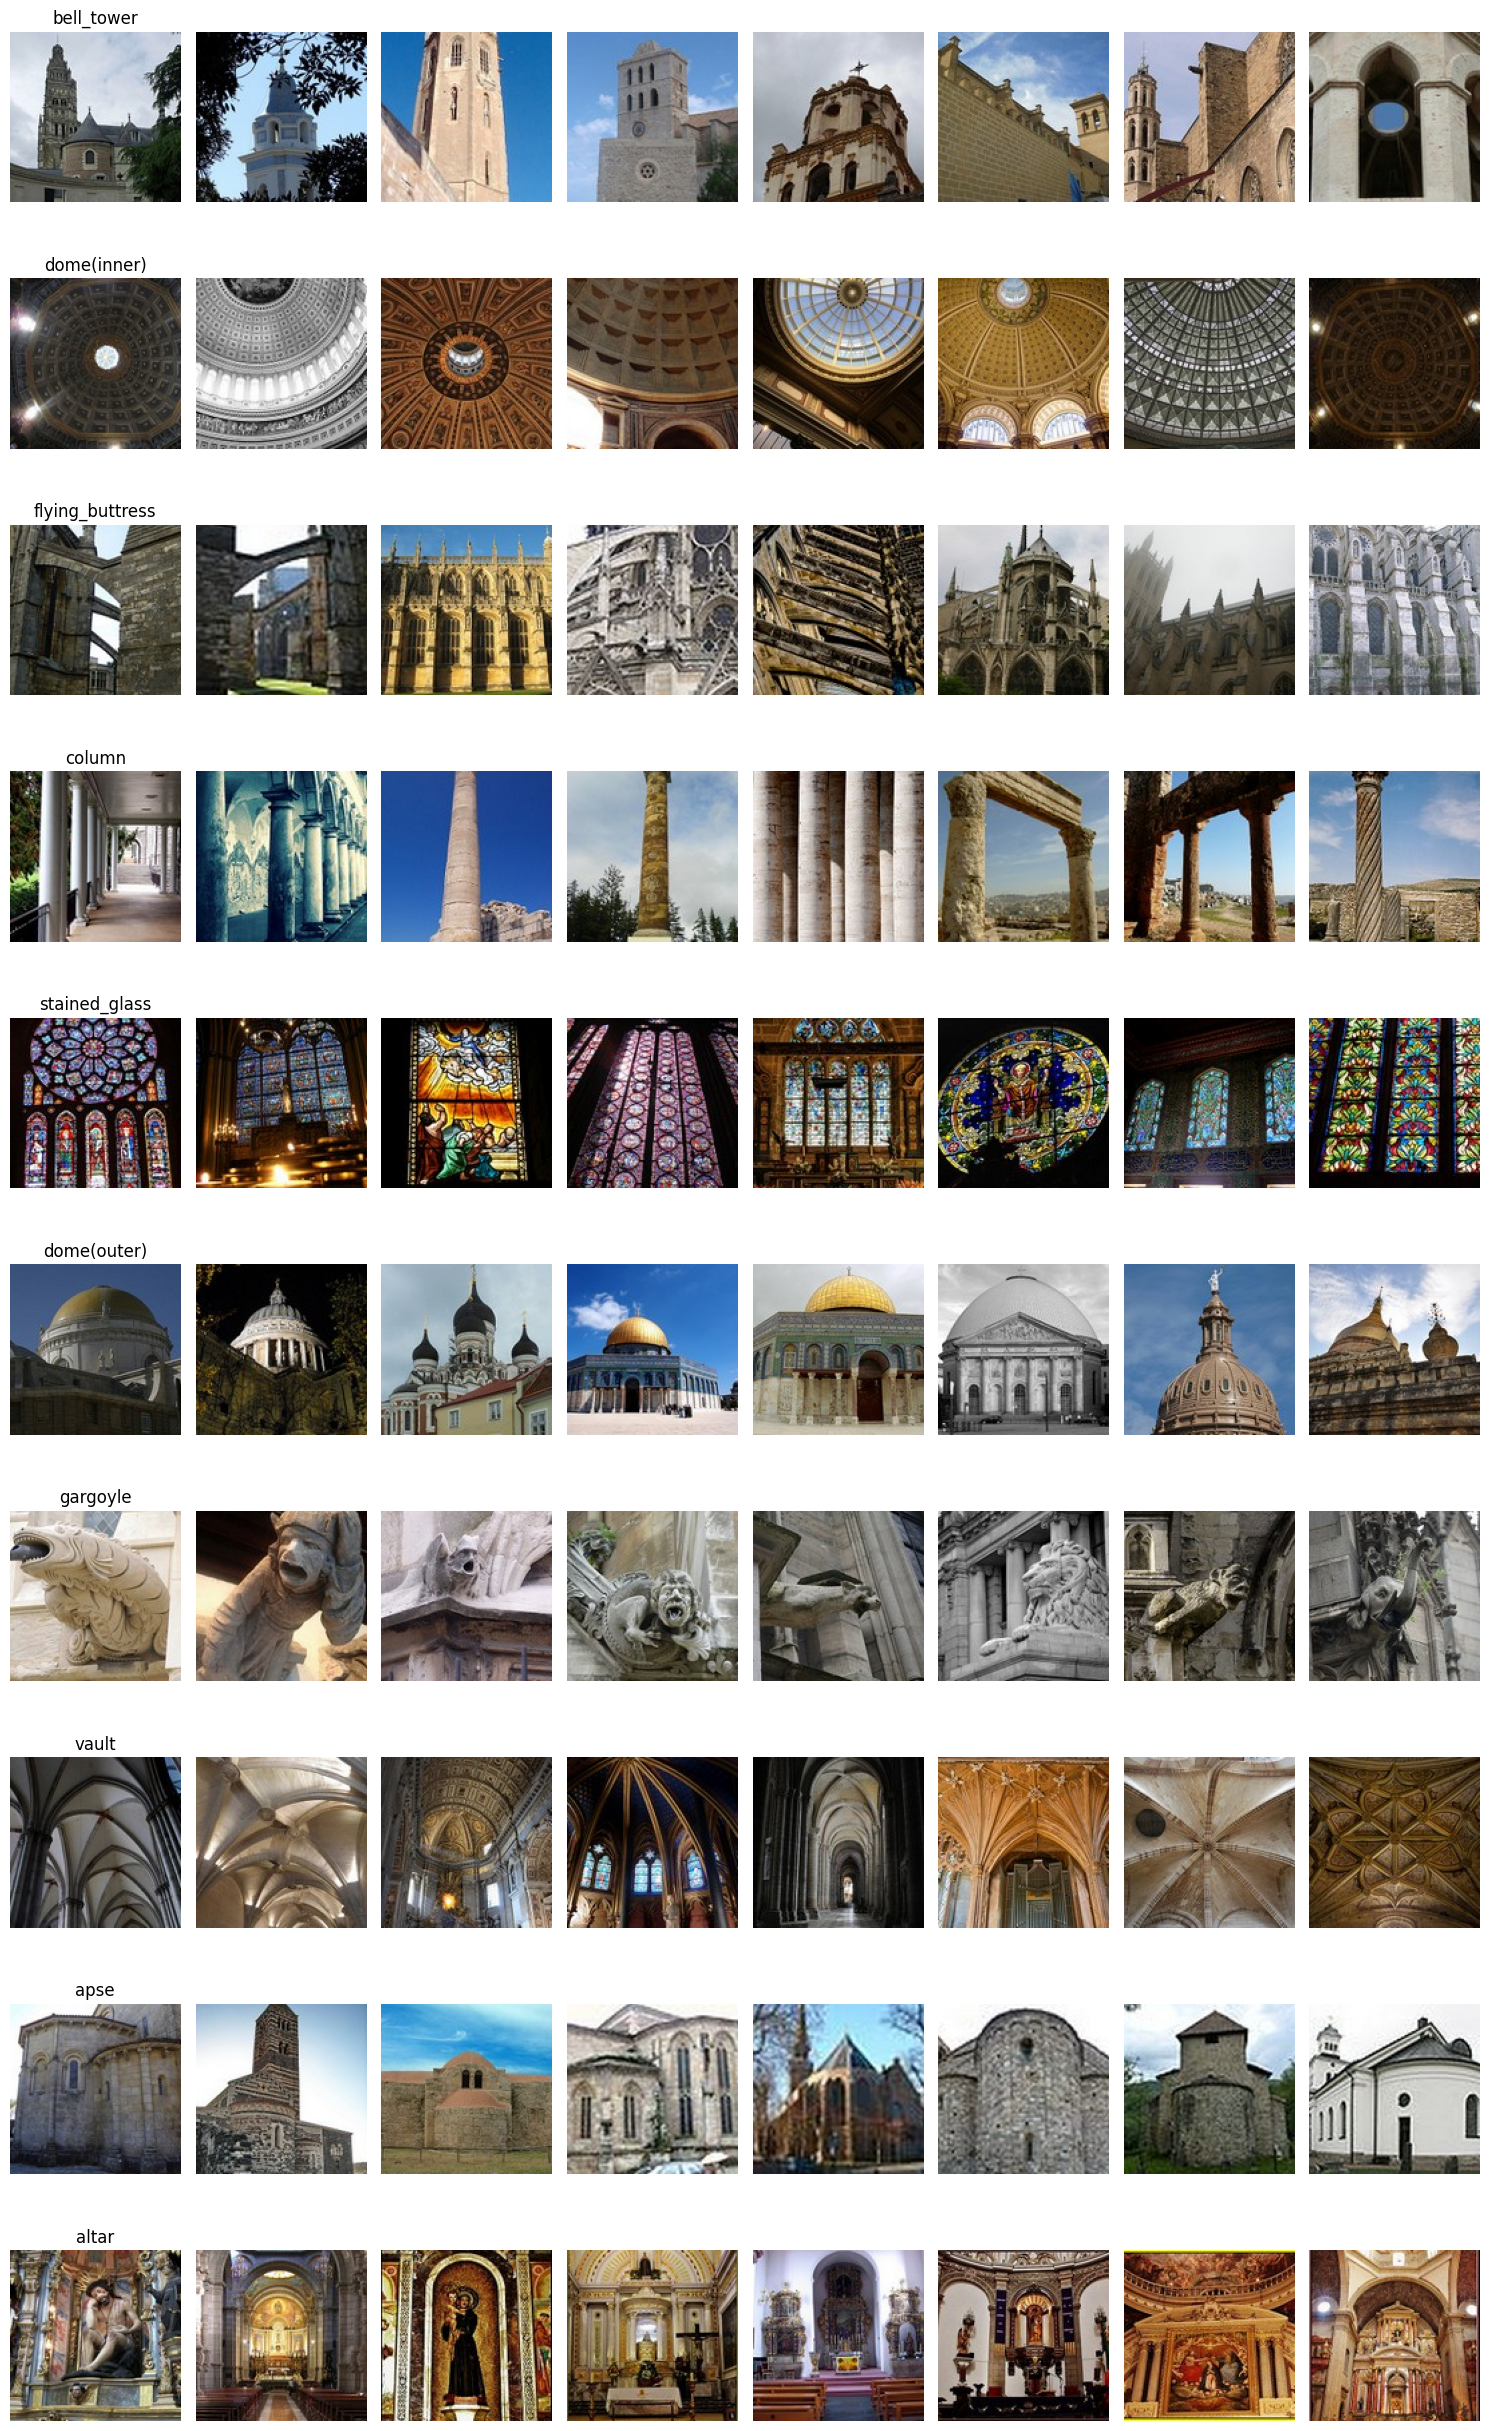

In [ ]:
list_image_stats(train_images_path)
plot_sample_images(train_images_path)


## 5. Preparing Data
Setup image data generators with augmentation for robust model training.


In [ ]:
train_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input, rescale=1./255, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input, rescale=1./255)

train_generator = train_datagen.flow_from_directory(os.path.join(output_images_path, 'train'), target_size=(224,224), batch_size=32, class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(os.path.join(output_images_path, 'val'), target_size=(224,224), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_images_path, target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)


Found 8264 images belonging to 10 classes.
Found 2072 images belonging to 10 classes.
Found 1554 images belonging to 10 classes.


## 6. Model Building & Training
Build the model, compile it, compute class weights, apply callbacks, and train.



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 522s 16s/step - accuracy: 0.2855 - loss: 2.0693 - precision: 0.6970 - recall: 0.0137 - val_accuracy: 0.7852 - val_loss: 1.0143 - val_precision: 0.9684 - val_recall: 0.3594 - learning_rate: 0.0010
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 497s 16s/step - accuracy: 0.7000 - loss: 1.1564 - precision: 0.9516 - recall: 0.3126 - val_accuracy: 0.7500 - val_loss: 0.7851 - val_precision: 0.9150 - val_recall: 0.5469 - learning_rate: 0.0010
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 368s 12s/step - accuracy: 0.7834 - loss: 0.8292 - precision: 0.9310 - recall: 0.5511 - val_accuracy: 0.7930 - val_loss: 0.6008 - val_precision: 0.8912 - val_recall: 0.6719 - learning_rate: 0.0010
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 281s 9s/step - accuracy: 0.7922 - loss: 0.7217 - precision: 0.9175 - recall: 0.6329 - val_accuracy: 0.8477 - val_loss: 0.4872 - val_precision: 0.9327 - val_recall: 0.7578 - learning_rate: 0.0010
Epoch 5/20
32/

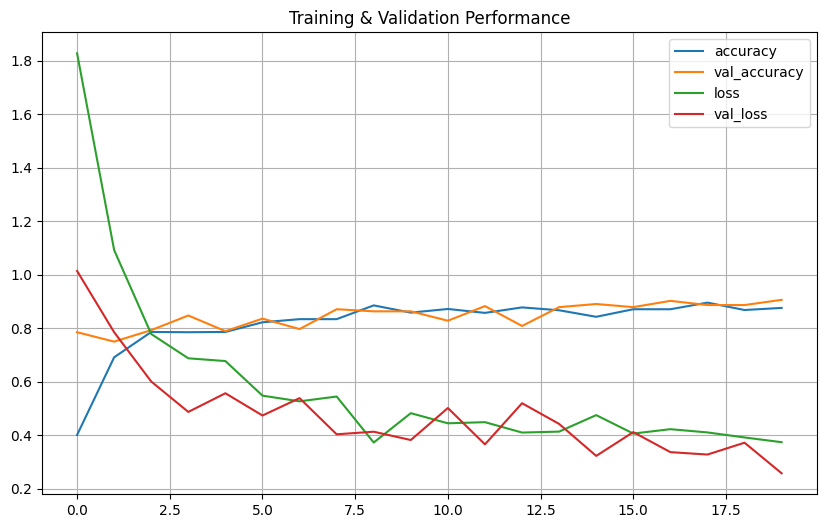

In [ ]:
model = create_model(num_classes=10)

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weights = dict(enumerate(class_weights))

early_stopping_cb = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 256,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 256,
    class_weight=class_weights,
    epochs=20,
    callbacks=[early_stopping_cb, reduce_lr_cb],
)

plot_training(history)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.8840 - loss: 0.3782 - precision_1: 0.9222 - recall_1: 0.8585 - val_accuracy: 0.8867 - val_loss: 0.3295 - val_precision_1: 0.9036 - val_recall_1: 0.8789 - learning_rate: 1.0000e-05
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8736 - loss: 0.3667 - precision_1: 0.9256 - recall_1: 0.8412 - val_accuracy: 0.8594 - val_loss: 0.3370 - val_precision_1: 0.8996 - val_recall_1: 0.8398 - learning_rate: 1.0000e-05
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9070 - loss: 0.3394 - precision_1: 0.9305 - recall_1: 0.8704 - val_accuracy: 0.9062 - val_loss: 0.2815 - val_precision_1: 0.9250 - val_recall_1: 0.8672 - learning_rate: 1.0000e-05
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9005 - loss: 0.3353 - precision_1: 0.9372 - recall_1: 0.8698 - val_accuracy: 0.9141 - val_loss: 0.2962 - val_precision_1: 0.9187 - val_recall_1: 0.8828 - learning_rate: 1.0000e-05
Epoch 5/20
32/32 ━━━━━━━

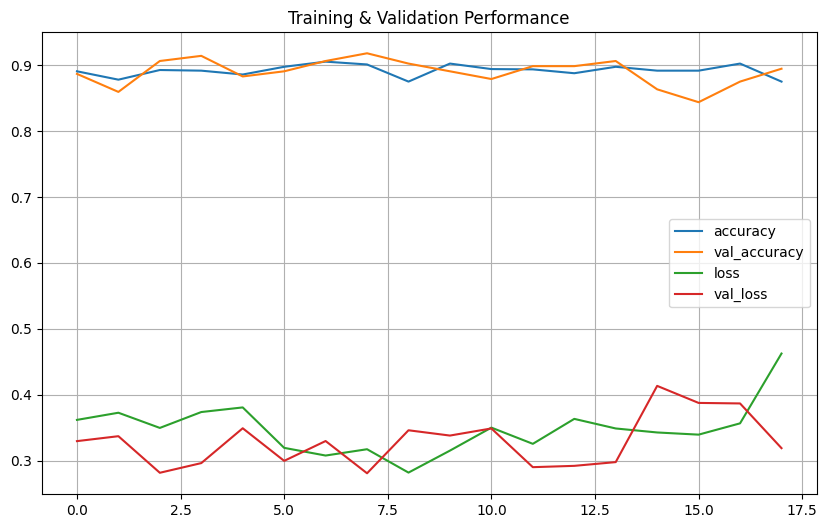

In [ ]:
model.trainable = True
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

fine_tune_history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 256,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // 256,
    class_weight=class_weights,
    epochs=20,
    callbacks=[early_stopping_cb, reduce_lr_cb],
)

plot_training(fine_tune_history)

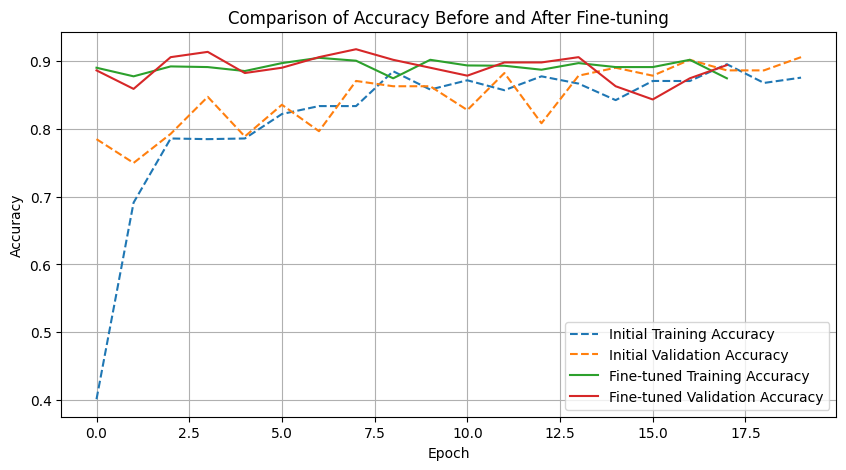

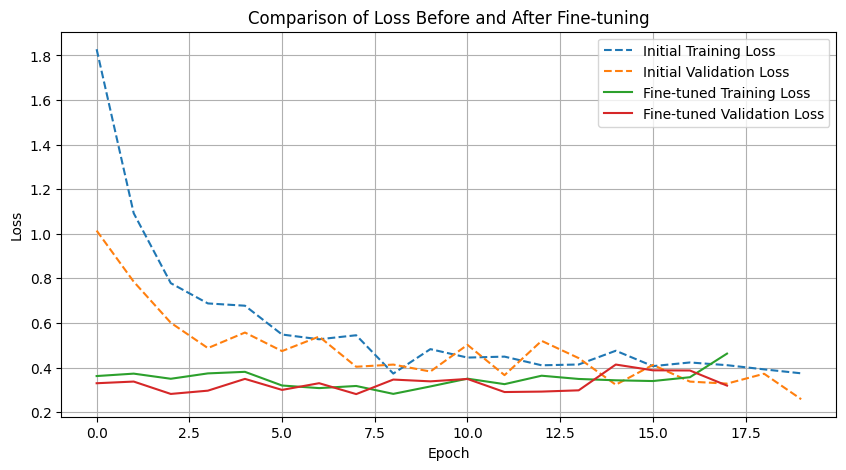

In [ ]:
# Determine the maximum number of epochs from both training histories
max_epochs = max(len(history.history['accuracy']), len(fine_tune_history.history['accuracy']))

# Pad the shorter history lists with NaN values
def pad_history(hist, max_epochs):
    padded_hist = {}
    for key, value in hist.history.items():
        padded_hist[key] = value + [np.nan] * (max_epochs - len(value))
    return padded_hist

padded_history = pad_history(history, max_epochs)
padded_fine_tune_history = pad_history(fine_tune_history, max_epochs)

combined_df = pd.DataFrame({
    'initial_acc': padded_history['accuracy'],
    'initial_val_acc': padded_history['val_accuracy'],
    'fine_acc': padded_fine_tune_history['accuracy'],
    'fine_val_acc': padded_fine_tune_history['val_accuracy'],
    'initial_loss': padded_history['loss'],
    'initial_val_loss': padded_history['val_loss'],
    'fine_loss': padded_fine_tune_history['loss'],
    'fine_val_loss': padded_fine_tune_history['val_loss'],
})

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(combined_df['initial_acc'], label='Initial Training Accuracy', linestyle='--')
plt.plot(combined_df['initial_val_acc'], label='Initial Validation Accuracy', linestyle='--')
plt.plot(combined_df['fine_acc'], label='Fine-tuned Training Accuracy')
plt.plot(combined_df['fine_val_acc'], label='Fine-tuned Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy Before and After Fine-tuning')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(combined_df['initial_loss'], label='Initial Training Loss', linestyle='--')
plt.plot(combined_df['initial_val_loss'], label='Initial Validation Loss', linestyle='--')
plt.plot(combined_df['fine_loss'], label='Fine-tuned Training Loss')
plt.plot(combined_df['fine_val_loss'], label='Fine-tuned Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Comparison of Loss Before and After Fine-tuning')
plt.legend()
plt.grid(True)
plt.show()

## 7. Model Evaluation
Evaluate performance on unseen test data.


In [ ]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.2f}, Precision: {test_prec:.2f}, Recall: {test_rec:.2f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 652s 14s/step - accuracy: 0.8105 - loss: 0.5702 - precision_1: 0.8442 - recall_1: 0.7832
Test Accuracy: 0.83, Precision: 0.86, Recall: 0.81


49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 202ms/step


<Figure size 1000x800 with 0 Axes>

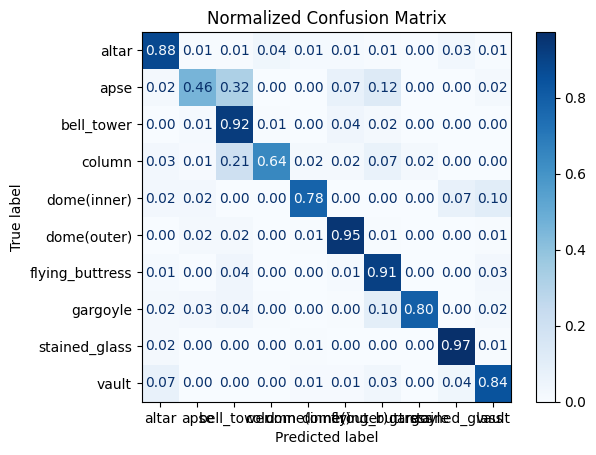

Classification Report (Per-Class Precision, Recall, F1-Score):
                 precision    recall  f1-score   support

          altar       0.80      0.88      0.84       140
           apse       0.62      0.46      0.53        57
     bell_tower       0.65      0.92      0.76       170
         column       0.96      0.64      0.77       239
    dome(inner)       0.87      0.78      0.82        86
    dome(outer)       0.88      0.95      0.91       168
flying_buttress       0.55      0.91      0.69        78
       gargoyle       0.98      0.80      0.88       240
  stained_glass       0.91      0.97      0.94       182
          vault       0.90      0.84      0.87       194

       accuracy                           0.83      1554
      macro avg       0.81      0.81      0.80      1554
   weighted avg       0.85      0.83      0.83      1554



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(test_generator)
y_true = test_generator.classes
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred_classes, normalize='true')
labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap='Blues', values_format='.2f')
plt.title('Normalized Confusion Matrix')
plt.grid(False)
plt.show()

# F1-score and Classification Report
from sklearn.metrics import classification_report

print("Classification Report (Per-Class Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred_classes, target_names=labels))

# Part 2. Building a Recommendation System
Build an item-based collaborative filtering recommendation system using cosine similarity.
The system suggests new tourist destinations to a user based on their previous ratings and
similarity between places rated by other users.

In [ ]:
# Load dataset
user_df = pd.read_csv("/content/drive/MyDrive/CapstoneProjectAssets/Capstone2/Part2/user.csv")

# User Data Inspection
print("User Data Info:")
user_df.info()

User Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User_Id   300 non-null    int64 
 1   Location  300 non-null    object
 2   Age       300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB


In [ ]:
print("\nUser Data Missing Values:")
print(user_df.isnull().sum())


User Data Missing Values:
User_Id     0
Location    0
Age         0
dtype: int64


In [ ]:
print("\nUser Data Duplicates:")
print(user_df.duplicated().sum())


User Data Duplicates:
0


This dataset contains information about the users.

- **Data Info**:

 - The dataset has 300 rows and 3 columns: User_Id, Location, and Age.

 - All columns have 300 non-null values, and the data types are appropriate.

- **Missing Values**: There are no missing values in this dataset.

- **Duplicates**: There are no duplicate rows.

In [ ]:
tourism_df = pd.read_excel("/content/drive/MyDrive/CapstoneProjectAssets/Capstone2/Part2/tourism_with_id.xlsx")
# Tourism Data Inspection
print("\nTourism Data Info:")
tourism_df.info()


Tourism Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 44.5+ KB


In [ ]:
tourism_df.head()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5


In [ ]:
print("\nTourism Data Missing Values:")
print(tourism_df.isnull().sum())


Tourism Data Missing Values:
Place_Id          0
Place_Name        0
Description       0
Category          0
City              0
Price             0
Rating            0
Time_Minutes    232
Coordinate        0
Lat               0
Long              0
Unnamed: 11     437
Unnamed: 12       0
dtype: int64


In [ ]:
print("\nTourism Data Duplicates:")
print(tourism_df.duplicated().sum())


Tourism Data Duplicates:
0


This dataset contains information about the tourist places.

- **Data Info**:

 - The dataset has 437 rows and 13 columns.

 - The columns include Place_Id, Place_Name, Category, City, Price, and Rating.

- **Missing Values**:

 - The **Time_Minutes** column has 232 missing values.

 - The **Unnamed**: 11 column is completely empty, with 437 missing values.

 - The **Unnamed**: 12 column has been read as a column, which seems to be an anomaly from the original excel file.

- **Duplicates**: There are no duplicate rows in the dataset.

In [ ]:
tourism_df.drop(columns=['Unnamed: 11', 'Unnamed: 12'], inplace=True)

In [ ]:
tourism_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 37.7+ KB


In [ ]:
# Calculate the median of the 'Time_Minutes' column
median_time = tourism_df['Time_Minutes'].median()

In [ ]:
# Fill missing values in 'Time_Minutes' with the median
tourism_df['Time_Minutes'].fillna(median_time, inplace=True)

In [ ]:
# Let's check the info again to confirm the changes
print("Tourism Data Info after handling missing values:")
tourism_df.info()

Tourism Data Info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  437 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 37.7+ KB


In [ ]:

print("\nMissing Values count after handling:")
print(tourism_df.isnull().sum())


Missing Values count after handling:
Place_Id        0
Place_Name      0
Description     0
Category        0
City            0
Price           0
Rating          0
Time_Minutes    0
Coordinate      0
Lat             0
Long            0
dtype: int64


In [ ]:
rating_df = pd.read_csv("/content/drive/MyDrive/CapstoneProjectAssets/Capstone2/Part2/tourism_rating.csv")
# Rating Data Inspection
print("\nRating Data Info:")
rating_df.info()


Rating Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


In [ ]:
print("\nRating Data Missing Values:")
print(rating_df.isnull().sum())


Rating Data Missing Values:
User_Id          0
Place_Id         0
Place_Ratings    0
dtype: int64


In [ ]:
print("\nRating Data Duplicates:")
print(rating_df.duplicated().sum())


Rating Data Duplicates:
79


This dataset contains the ratings given by users to the tourist places.

- **Data Info**:

 - The dataset has 10,000 rows and 3 columns: User_Id, Place_Id, and Place_Ratings.

 - All columns are of integer type and have no missing values.
- **Missing Values**: There are no missing values.

- **Duplicates**: Initially, there were 79 duplicate rows, which have been removed.



In [ ]:
rating_df.drop_duplicates(inplace=True)

In [ ]:
print("\nRating Data Duplicates:")
print(rating_df.duplicated().sum())


Rating Data Duplicates:
0


In [ ]:
rating_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9921 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        9921 non-null   int64
 1   Place_Id       9921 non-null   int64
 2   Place_Ratings  9921 non-null   int64
dtypes: int64(3)
memory usage: 310.0 KB


# Data Exploration: Understanding the Tourists


### Age Distribution of Users

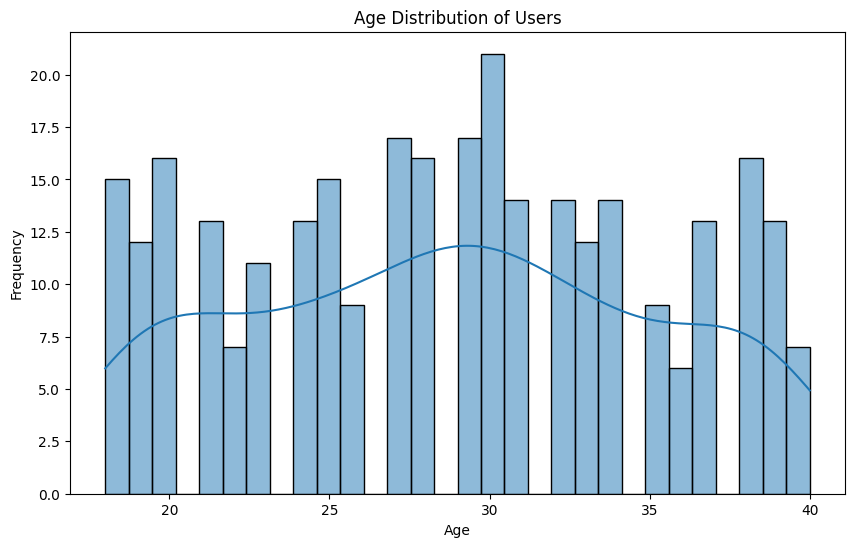

In [ ]:
# Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(user_df['Age'], bins=30, kde=True)
plt.title('Age Distribution of Users')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


The histogram above shows that the users are distributed across a wide range of ages, with a significant concentration of users in the 20-40 age group.

### User Locations

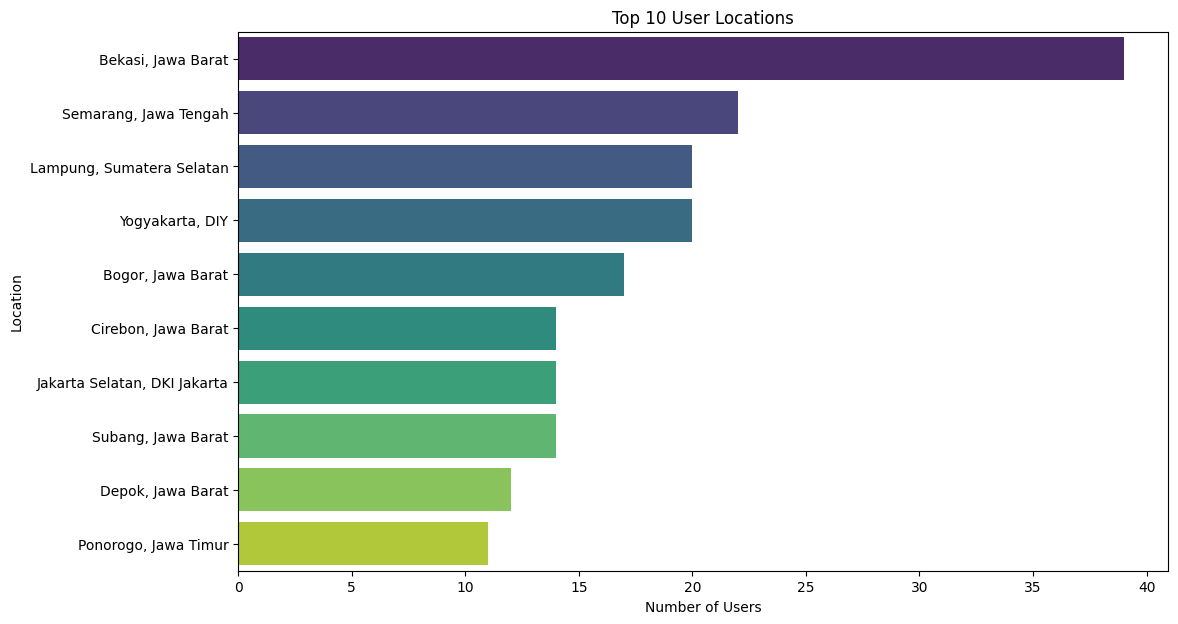

In [ ]:
# Location Analysis
# To make the plot readable, let's take the top 10 locations
top_locations = user_df['Location'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Top 10 User Locations')
plt.xlabel('Number of Users')
plt.ylabel('Location')
plt.show()

The bar chart aboce shows the top 10 locations with the highest number of users in this dataset. Jakarta, Bandung, and Yogyakarta are the top three locations from where most of the users are.

In [ ]:
# --- I. What are the different categories of tourist spots? ---
unique_categories = tourism_df['Category'].unique()
print("Different categories of tourist spots:")
for category in unique_categories:
    print(f"- {category}")


Different categories of tourist spots:
- Budaya
- Taman Hiburan
- Cagar Alam
- Bahari
- Pusat Perbelanjaan
- Tempat Ibadah


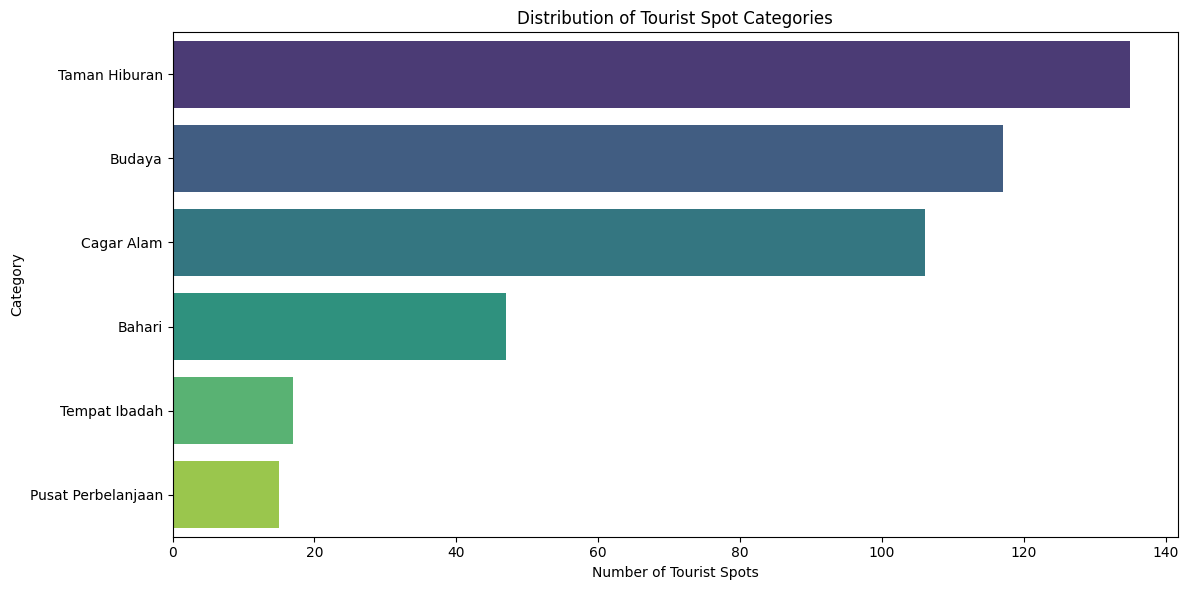

In [ ]:
# Plotting the distribution of categories
plt.figure(figsize=(12, 6))
sns.countplot(data=tourism_df, y='Category', order=tourism_df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Tourist Spot Categories')
plt.xlabel('Number of Tourist Spots')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
# Analyze tourism suitability per city and identifying best for nature enthusiasts
nature_categories = ['Cagar Alam', 'Bahari']
df_nature = tourism_df[tourism_df['Category'].isin(nature_categories)]
nature_city_counts = df_nature['City'].value_counts().reset_index()
nature_city_counts.columns = ['City', 'Nature_Spots']

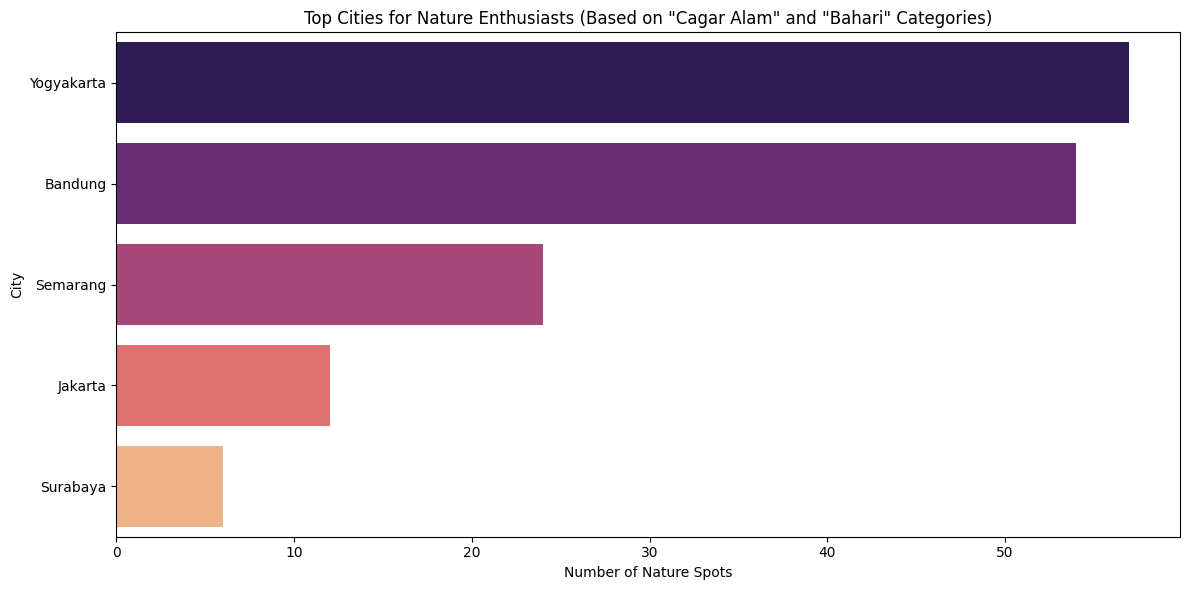

In [ ]:
# Plotting top cities for nature enthusiasts
plt.figure(figsize=(12, 6))
sns.barplot(data=nature_city_counts.head(10), x='Nature_Spots', y='City', palette='magma')
plt.title('Top Cities for Nature Enthusiasts (Based on "Cagar Alam" and "Bahari" Categories)')
plt.xlabel('Number of Nature Spots')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [ ]:
# Merge the two DataFrames on 'Place_Id'
df_combined = pd.merge(tourism_df, rating_df, on='Place_Id', how='inner')

# Display the first 5 rows of the combined DataFrame
print("First 5 rows of the combined DataFrame:")
df_combined.head()

First 5 rows of the combined DataFrame:


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,User_Id,Place_Ratings
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,36,4
1,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,38,2
2,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,64,2
3,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,74,2
4,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,86,4


In [ ]:

# Display column names and their data types for the combined DataFrame
print("\nInfo for the combined DataFrame:")
print(df_combined.info())


Info for the combined DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9921 entries, 0 to 9920
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Place_Id       9921 non-null   int64  
 1   Place_Name     9921 non-null   object 
 2   Description    9921 non-null   object 
 3   Category       9921 non-null   object 
 4   City           9921 non-null   object 
 5   Price          9921 non-null   int64  
 6   Rating         9921 non-null   float64
 7   Time_Minutes   9921 non-null   float64
 8   Coordinate     9921 non-null   object 
 9   Lat            9921 non-null   float64
 10  Long           9921 non-null   float64
 11  User_Id        9921 non-null   int64  
 12  Place_Ratings  9921 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 1007.7+ KB
None


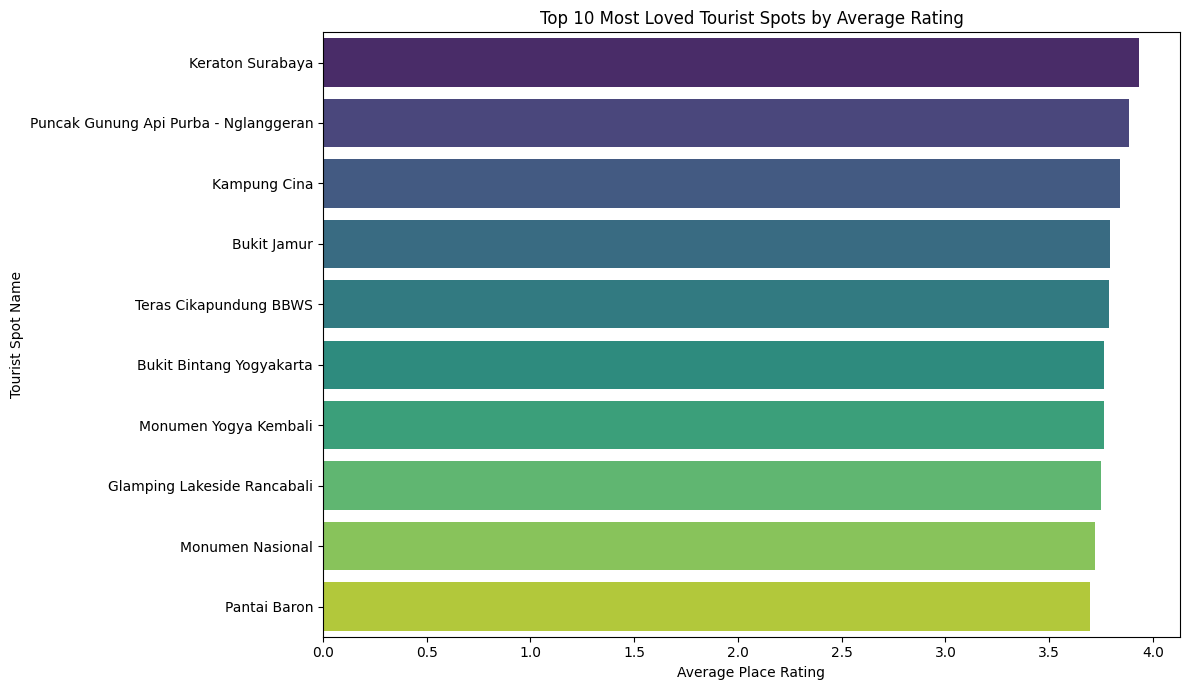

In [ ]:
# Calculate the average rating for each place
most_loved_spots = df_combined.groupby('Place_Name')['Place_Ratings'].mean().sort_values(ascending=False).reset_index()

# Get the top 10 most loved spots
top_10_spots = most_loved_spots.head(10)

# Plotting the most loved tourist spots
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_spots, x='Place_Ratings', y='Place_Name', palette='viridis')
plt.title('Top 10 Most Loved Tourist Spots by Average Rating')
plt.xlabel('Average Place Rating')
plt.ylabel('Tourist Spot Name')
plt.tight_layout()
plt.show()


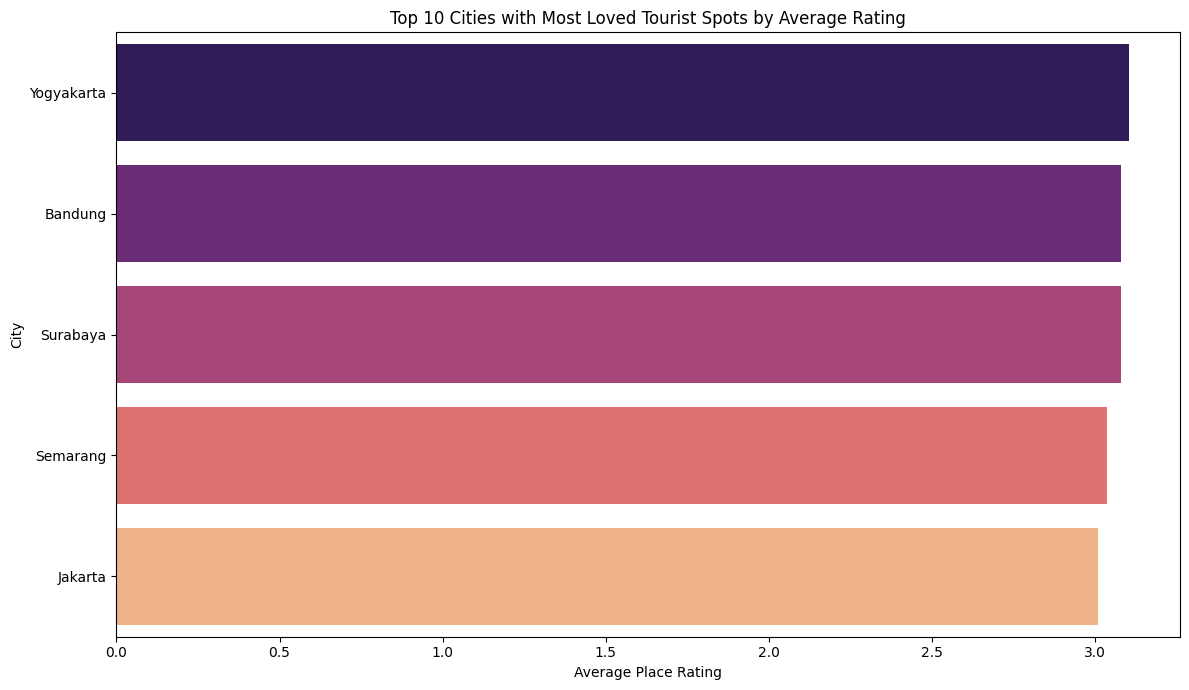

In [ ]:
# Calculate the average rating for each city
most_loved_cities = df_combined.groupby('City')['Place_Ratings'].mean().sort_values(ascending=False).reset_index()

# Get the top 10 cities with most loved spots
top_10_cities = most_loved_cities.head(10)

# Plotting the cities with most loved tourist spots
plt.figure(figsize=(12, 7))
sns.barplot(data=top_10_cities, x='Place_Ratings', y='City', palette='magma')
plt.title('Top 10 Cities with Most Loved Tourist Spots by Average Rating')
plt.xlabel('Average Place Rating')
plt.ylabel('City')
plt.tight_layout()
plt.show()

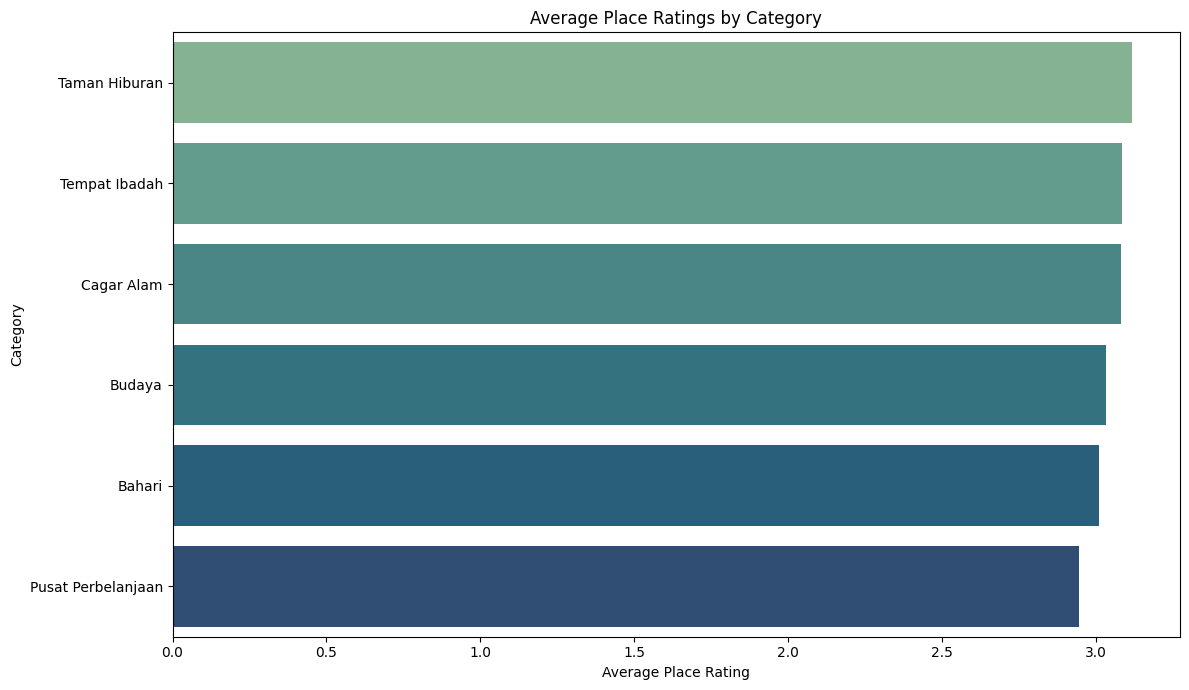

Most liked category:
|               | 0                  |
|:--------------|:-------------------|
| Category      | Taman Hiburan      |
| Place_Ratings | 3.1183862433862433 |


In [ ]:
# Calculate the average rating for each category
category_ratings = df_combined.groupby('Category')['Place_Ratings'].mean().sort_values(ascending=False).reset_index()

# Plotting the average ratings per category
plt.figure(figsize=(12, 7))
sns.barplot(data=category_ratings, x='Place_Ratings', y='Category', palette='crest')
plt.title('Average Place Ratings by Category')
plt.xlabel('Average Place Rating')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Identify the most liked category
most_liked_category = category_ratings.iloc[0]
print("Most liked category:")
print(most_liked_category.to_markdown(numalign="left", stralign="left"))

Based on the average user ratings, Taman Hiburan (Amusement Parks) is the category of places that users are liking the most in Indonesia. It has the highest average rating among all categories.


In [ ]:
# Create a mapping from Place_Id to Place_Name and vice versa for easy lookup
place_id_to_name = df_combined.set_index('Place_Id')['Place_Name'].drop_duplicates().to_dict()
place_name_to_id = {v: k for k, v in place_id_to_name.items()}
place_name_to_id

{'Monumen Nasional': 1,
 'Kota Tua': 2,
 'Dunia Fantasi': 3,
 'Taman Mini Indonesia Indah (TMII)': 4,
 'Atlantis Water Adventure': 5,
 'Taman Impian Jaya Ancol': 6,
 'Kebun Binatang Ragunan': 7,
 'Ocean Ecopark': 8,
 'Pelabuhan Marina': 9,
 'Pulau Tidung': 10,
 'Pulau Bidadari': 11,
 'Pulau Pari': 12,
 'Pulau Pramuka': 13,
 'Pulau Pelangi': 14,
 'Pasar Seni': 15,
 'Jembatan Kota Intan': 16,
 'Museum Fatahillah': 17,
 'Museum Bank Indonesia': 18,
 'Kidzania': 19,
 'Museum Taman Prasasti': 20,
 'Museum Wayang': 21,
 'Masjid Istiqlal': 22,
 'Gereja Katedral': 23,
 'Museum Nasional': 24,
 'Pasar Tanah Abang': 25,
 'Pecinan Glodok': 26,
 'Sea World': 27,
 'Wisata Agro Edukatif Istana Susu Cibugary': 28,
 'Wisata Kuliner Pecenongan': 29,
 'Taman Menteng': 30,
 'Wisata Alam Mangrove Angke': 31,
 'Setu Babakan': 32,
 'Taman Suropati': 33,
 'Pasar Taman Puring': 34,
 'Grand Indonesia Mall': 35,
 'Skyrink - Mall Taman Anggrek': 36,
 'Bumi Perkemahan Cibubur': 37,
 'Istana Negara Republik Indones

In [ ]:
# Create the user-item matrix (rating_matrix)
rating_matrix = df_combined.pivot_table(index='User_Id', columns='Place_Id', values='Place_Ratings').fillna(0)
rating_matrix.head()

Place_Id,1,2,3,4,5,6,7,8,9,10,...,428,429,430,431,432,433,434,435,436,437
User_Id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,5.0,0.0


In [ ]:
# Create the item-feature matrix (transpose of rating_matrix)
# This is needed for item-based collaborative filtering, where we find similarities between items
place_user_matrix = rating_matrix.T
place_user_matrix

User_Id,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
Place_Id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,4.0,3.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
433,0.0,0.0,0.0,0.0,4.0,4.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
434,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [ ]:
# Create a pivot table where rows = users, columns = places, and values = ratings
rating_matrix = rating_df.pivot_table(index='User_Id', columns='Place_Id', values='Place_Ratings').fillna(0)
rating_matrix.head()

Place_Id,1,2,3,4,5,6,7,8,9,10,...,428,429,430,431,432,433,434,435,436,437
User_Id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,4.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0,5.0,0.0


In [ ]:
# Calculate the cosine similarity between places
cosine_sim_matrix = cosine_similarity(place_user_matrix)
# Convert the similarity matrix to a DataFrame for easier indexing
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=place_user_matrix.index, columns=place_user_matrix.index)

In [ ]:
cosine_sim_df.head()

Place_Id,1,2,3,4,5,6,7,8,9,10,...,428,429,430,431,432,433,434,435,436,437
Place_Id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.095540,0.252406,0.064487,0.066435,0.000000,0.020106,0.025804,0.009279,0.065436,...,0.125985,0.007770,0.006259,0.028021,0.080238,0.000000,0.054517,0.000000,0.146756,0.064556
2,0.095540,1.000000,0.053904,0.000000,0.072358,0.045977,0.065695,0.033375,0.000000,0.201932,...,0.160087,0.101547,0.093736,0.030519,0.043696,0.003815,0.064326,0.000000,0.025238,0.129437
3,0.252406,0.053904,1.000000,0.022740,0.000000,0.010826,0.000000,0.027298,0.052354,0.000000,...,0.098723,0.000000,0.026486,0.000000,0.045270,0.000000,0.128162,0.183296,0.000000,0.000000
4,0.064487,0.000000,0.022740,1.000000,0.137361,0.000000,0.069284,0.055576,0.165212,0.081428,...,0.036179,0.066935,0.008987,0.000000,0.000000,0.112654,0.130463,0.124392,0.097596,0.008427
5,0.066435,0.072358,0.000000,0.137361,1.000000,0.063578,0.000000,0.058018,0.043923,0.000000,...,0.198781,0.128719,0.091845,0.033159,0.045576,0.000000,0.043009,0.000000,0.036561,0.050003


In [ ]:
def recommend_places(place_name, n_recommendations=5):
    """
    Recommends other places to visit based on a given tourist location using item-based collaborative filtering.

    Args:
        place_name (str): The name of the current tourist location.
        n_recommendations (int): The number of recommendations to provide.

    Returns:
        list: A list of recommended place names.
    """
    if place_name not in place_name_to_id:
        return f"Place '{place_name}' not found in the dataset. Please try another place."

    place_id = place_name_to_id[place_name]

    # Get the similarity scores for the given place with all other places
    sim_scores = cosine_sim_df[place_id]

    # Sort the places by similarity scores in descending order, excluding the place itself
    # Use reset_index(drop=True) after dropna() to avoid issues when using iloc later.
    similar_places = sim_scores.sort_values(ascending=False).drop(place_id).reset_index()

    # Get the top N recommended place IDs
    recommended_place_ids = similar_places.head(n_recommendations)['Place_Id'].tolist()

    # Map Place_Ids back to Place_Names
    recommended_place_names = [place_id_to_name[pid] for pid in recommended_place_ids]

    return recommended_place_names

In [ ]:
# Test the recommender model with an example
example_place = 'Monumen Nasional'
recommendations = recommend_places(example_place)

print(f"\nRecommendations for '{example_place}':")
print(recommendations)



Recommendations for 'Monumen Nasional':
['Wisata Mangrove Tapak', 'Danau Rawa Pening', 'Museum Sonobudoyo Unit I', 'Dunia Fantasi', 'Situ Patenggang']


In [ ]:

# Test with another example
example_place_2 = 'Candi Prambanan'
recommendations_2 = recommend_places(example_place_2)

print(f"\nRecommendations for '{example_place_2}':")
print(recommendations_2)



Recommendations for 'Candi Prambanan':
['Masjid Muhammad Cheng Hoo', 'Bukit Panguk Kediwung', 'Kebun Teh Nglinggo', 'Taman Bunga Celosia', 'Taman Harmoni Keputih']


In [ ]:

# Test with a place not in the dataset
example_place_not_found = 'NonExistent Place'
recommendations_not_found = recommend_places(example_place_not_found)

print(f"\nRecommendations for '{example_place_not_found}':")
print(recommendations_not_found)


Recommendations for 'NonExistent Place':
Place 'NonExistent Place' not found in the dataset. Please try another place.


###  Summary
This notebook showcases an end-to-end AI solution that classifies historical structures using deep learning and recommends tourist locations using collaborative filtering.

- **Image Classification**: Transfer learning with VGG16 to predict architectural categories.
- **Model Evaluation**: Performance measured via accuracy, precision, recall, and F1-score.
- **EDA**: In-depth data exploration of both image and tourism datasets.
- **Recommendation System**: Item-based collaborative filtering using cosine similarity.

This project demonstrates real-world applications in tourism tech and cultural heritage preservation.
